In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('asthma_balanced.csv')

X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

lr_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train_balanced)

rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)

print("Models trained successfully!")


joblib.dump(lr_model, 'lr_model.pkl')
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

X_test.to_csv('X_test.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("Saved: lr_model.pkl, rf_model.pkl, scaler.pkl, X_test.csv, y_test.csv")

Before SMOTE: {0: 1814, 1: 99}
After SMOTE: {0: 1814, 1: 1814}
Models trained successfully!
Saved: lr_model.pkl, rf_model.pkl, scaler.pkl, X_test.csv, y_test.csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss


In [ ]:
df = pd.read_csv('asthma_balanced.csv')
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_val_scaled = scaler.transform(X_val)

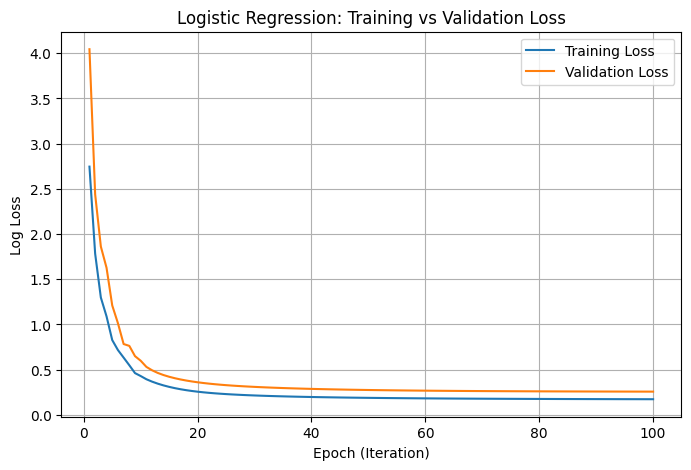

Final Training Loss: 0.1727
Final Validation Loss: 0.2566


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

n_epochs = 100

# class_weight='balanced' hata diya, sample_weight se balance karenge
sgd_model = SGDClassifier(loss='log_loss', random_state=42)

# balanced sample weights nikal lo (ek dafa)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_bal)

train_losses = []
val_losses = []
classes = np.unique(y_train_bal)

for epoch in range(n_epochs):
    sgd_model.partial_fit(
        X_train_scaled, y_train_bal,
        classes=classes,
        sample_weight=sample_weights
    )

    train_proba = sgd_model.predict_proba(X_train_scaled)
    val_proba = sgd_model.predict_proba(X_val_scaled)

    train_loss = log_loss(y_train_bal, train_proba)
    val_loss = log_loss(y_val, val_proba)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, n_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch (Iteration)')
plt.ylabel('Log Loss')
plt.title('Logistic Regression: Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

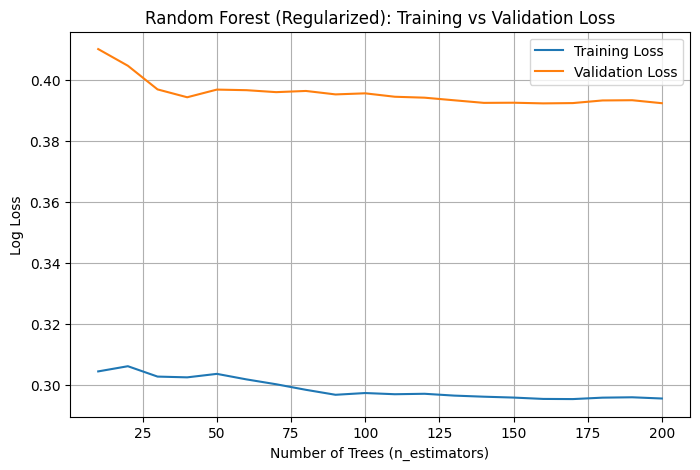

Final Training Loss: 0.2956
Final Validation Loss: 0.3924


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

tree_counts = list(range(10, 210, 10))
rf_train_losses = []
rf_val_losses = []

for n_trees in tree_counts:
    rf_model = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        class_weight='balanced',
        random_state=42
    )
    rf_model.fit(X_train_bal, y_train_bal)

    train_proba = rf_model.predict_proba(X_train_bal)
    val_proba = rf_model.predict_proba(X_val)

    rf_train_losses.append(log_loss(y_train_bal, train_proba))
    rf_val_losses.append(log_loss(y_val, val_proba))

plt.figure(figsize=(8, 5))
plt.plot(tree_counts, rf_train_losses, label='Training Loss')
plt.plot(tree_counts, rf_val_losses, label='Validation Loss')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Log Loss')
plt.title('Random Forest (Regularized): Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Training Loss: {rf_train_losses[-1]:.4f}")
print(f"Final Validation Loss: {rf_val_losses[-1]:.4f}")